In [1]:
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from decord import VideoReader, cpu

# Which dataset to preprocess:
#   "pangaea" - PVotSky sky imager (colour, disk fully inside the frame)
#   "uoh"     - Univ. of Hertfordshire all-sky camera (grayscale, disk clipped
#               by the frame edges, no JSON sidecar metadata)
DATASET = "pangaea"

# Candidate locations for each dataset, tried in order. Relative paths cover
# running the notebook from preprocessing/ or from the repo root.
DATASET_DIRS = {
    "pangaea": [
        Path.cwd() / "data" / "raw_data" / "pangaea" / "PVotSky",
        Path.cwd() / "preprocessing" / "data" / "raw_data" / "pangaea" / "PVotSky",
    ],
    "uoh": [
        Path("/data/raw_data/uoh"),
        Path.cwd() / "data" / "raw_data" / "uoh",
        Path.cwd() / "preprocessing" / "data" / "raw_data" / "uoh",
    ],
}

VIDEO_DIR = next((p.resolve() for p in DATASET_DIRS[DATASET]
                  if p.is_dir() and any(p.rglob("*.mp4"))), None)
if VIDEO_DIR is None:
    raise FileNotFoundError(f"No videos found for dataset {DATASET!r} in "
                            f"{[str(p) for p in DATASET_DIRS[DATASET]]}")

video_paths = sorted(VIDEO_DIR.rglob("*.mp4"))
print(f"Dataset   : {DATASET}")
print(f"Video dir : {VIDEO_DIR}")
print(f"Found {len(video_paths)} videos "
      f"({video_paths[0].stem} … {video_paths[-1].stem})")

Dataset   : pangaea
Video dir : /home/ubuntu/PVOutputPrediction/preprocessing/data/raw_data/pangaea/PVotSky
Found 731 videos (20220801 … 20240731)


In [2]:
def load_metadata(video_path):
    """Return the sidecar JSON metadata for a video, or None if missing."""
    meta_path = video_path.with_suffix(".json")
    if meta_path.exists():
        with open(meta_path) as f:
            return json.load(f)
    return None


def read_frames(video_path, num_frames=6, indices=None):
    """Read `num_frames` evenly-spaced RGB frames from a video.

    Returns (frames, indices) where frames is a list of HxWx3 uint8 arrays.
    """
    vr = VideoReader(str(video_path), ctx=cpu(0))
    total = len(vr)
    if indices is None:
        indices = np.linspace(0, total - 1, num=min(num_frames, total), dtype=int)
    indices = list(indices)
    frames = vr.get_batch(indices).asnumpy()  # (N, H, W, 3), RGB
    return frames, indices


def frame_timestamp(meta, index):
    """Look up the timestamp for a frame index from metadata, if available."""
    if not meta:
        return None
    frames = meta.get("frames", [])
    if 0 <= index < len(frames):
        return frames[index].get("timestamp")
    return None


def show_frames(frames, titles=None, suptitle=None, cols=3, scale=4):
    """Plot a list/array of RGB frames in a grid."""
    n = len(frames)
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * scale, rows * scale))
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(frames[i])
            if titles is not None:
                ax.set_title(titles[i], fontsize=9)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    plt.show()

20220801.mp4: [2048, 2112] @ 10 fps, 779 frames, date 2022-08-01


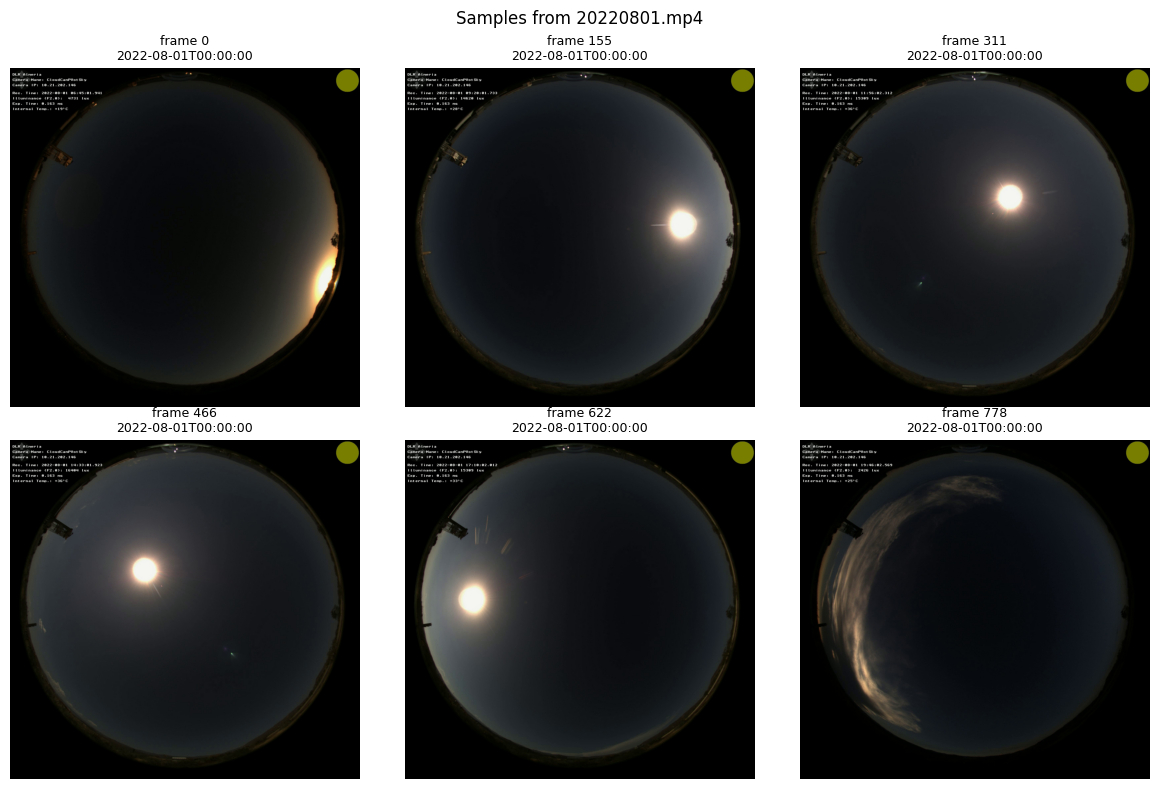

In [3]:
# --- Sample frames across a single day -------------------------------------
sample_video = video_paths[0]
meta = load_metadata(sample_video)
if meta:
    print(f"{sample_video.name}: {meta['resolution']} @ {meta['fps']} fps, "
          f"{meta['frame_count']} frames, date {meta['date']}")

frames, idxs = read_frames(sample_video, num_frames=6)
titles = []
for idx in idxs:
    ts = frame_timestamp(meta, idx)
    titles.append(f"frame {idx}" + (f"\n{ts}" if ts else ""))

show_frames(frames, titles=titles, suptitle=f"Samples from {sample_video.name}")

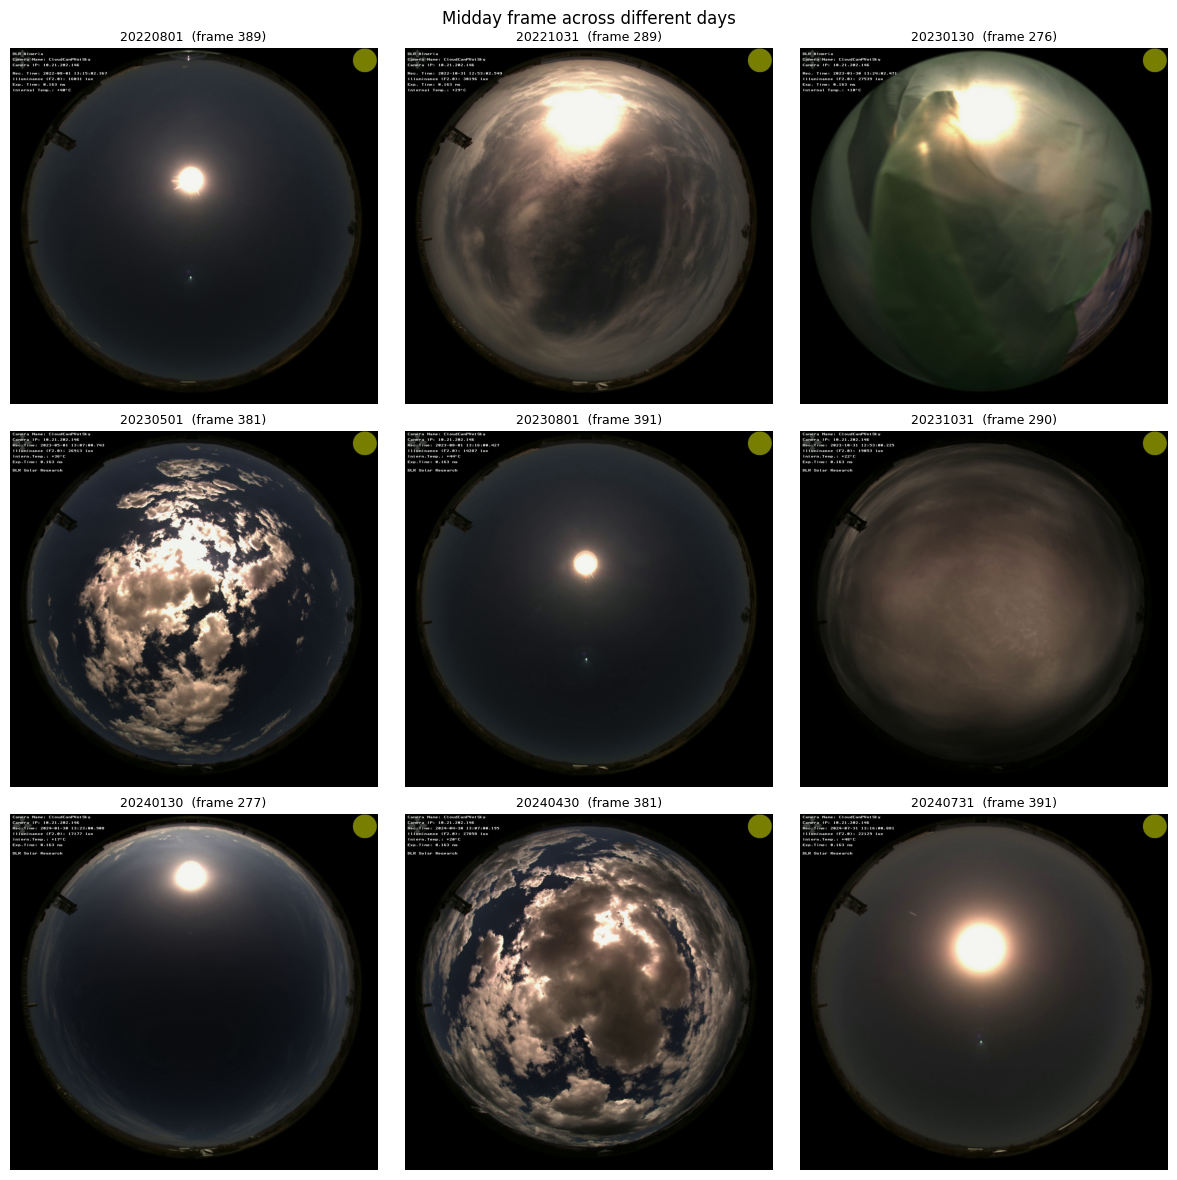

In [4]:
# --- One mid-day frame from several different days --------------------------
num_days = 9
chosen = np.linspace(0, len(video_paths) - 1, num=num_days, dtype=int)

day_frames, day_titles = [], []
for i in chosen:
    vp = video_paths[i]
    vr = VideoReader(str(vp), ctx=cpu(0))
    mid = len(vr) // 2  # midday ~ middle of the daytime clip
    day_frames.append(vr[mid].asnumpy())
    day_titles.append(f"{vp.stem}  (frame {mid})")

show_frames(day_frames, titles=day_titles,
            suptitle="Midday frame across different days", cols=3)

## Crop guides

The cells below overlay a red grid (with pixel-coordinate labels) so you can read
off where to crop. Adjust `CROP` = `(x0, y0, x1, y1)` and re-run to preview a
candidate crop box (drawn in lime) and the resulting cropped image.

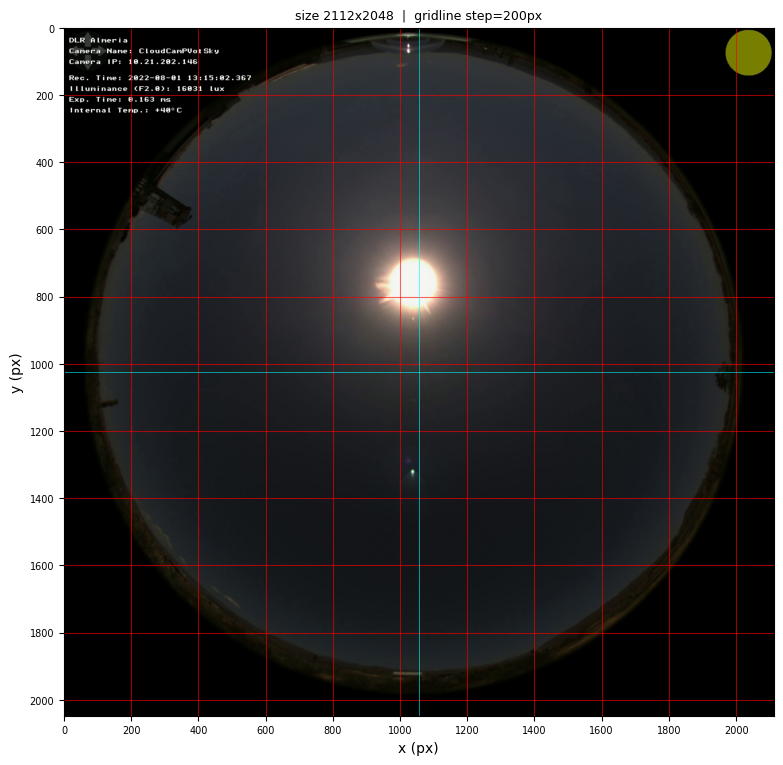

In [5]:
def show_crop_guides(frame, step=200, crop=None, scale=8, line_alpha=0.6):
    """Show a frame with a red gridline overlay to help pick crop coordinates.

    Args:
        frame: HxWx3 RGB array.
        step:  spacing (in pixels) between gridlines.
        crop:  optional (x0, y0, x1, y1) box to preview, drawn in lime.
        scale: figure size scale.
        line_alpha: opacity of the red gridlines.
    """
    h, w = frame.shape[:2]
    fig, ax = plt.subplots(figsize=(scale, scale * h / w))
    ax.imshow(frame)

    xs = np.arange(0, w, step)
    ys = np.arange(0, h, step)

    # Red gridlines.
    for x in xs:
        ax.axvline(x, color="red", linewidth=0.8, alpha=line_alpha)
    for y in ys:
        ax.axhline(y, color="red", linewidth=0.8, alpha=line_alpha)

    # Emphasize the image centre.
    ax.axvline(w / 2, color="cyan", linewidth=0.5, alpha=0.8)
    ax.axhline(h / 2, color="cyan", linewidth=0.5, alpha=0.8)

    # Coordinate ticks on the axes.
    ax.set_xticks(xs)
    ax.set_yticks(ys)
    ax.tick_params(labelsize=7)
    ax.set_xlabel("x (px)")
    ax.set_ylabel("y (px)")

    # Optional candidate crop box.
    if crop is not None:
        x0, y0, x1, y1 = crop
        rect = plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                             edgecolor="lime", facecolor="none", linewidth=2)
        ax.add_patch(rect)
        ax.set_title(f"size {w}x{h}  |  crop=(x0={x0}, y0={y0}, x1={x1}, y1={y1}) "
                     f"-> {x1 - x0}x{y1 - y0}", fontsize=9)
    else:
        ax.set_title(f"size {w}x{h}  |  gridline step={step}px", fontsize=9)

    fig.tight_layout()
    plt.show()


# Grab a frame to inspect (midday frame of the first video).
_vr = VideoReader(str(sample_video), ctx=cpu(0))
guide_frame = _vr[len(_vr) // 2].asnumpy()

# Step 1: view the grid to read off coordinates (finer grid for small frames).
grid_step = 200 if guide_frame.shape[1] > 1000 else 50
show_crop_guides(guide_frame, step=grid_step)

## Auto-detect the crop

Both imagers produce a bright circular disk on a black background, so we can
find the crop automatically: threshold the non-black region, take the largest
blob, and fit a circle. The cameras are fixed, so the detected circle is stable
across days and a single square crop works per dataset. For UOH the disk spills
past the frame edges, so the square crop shrinks to the frame height while
staying centred on the disk.

Pipeline (per the crop-vs-downscale discussion): **crop to the square disk first,
then resize to 224×224 with area-averaging** (`cv2.INTER_AREA`) to avoid aliasing.

detected circle: center=(322, 205) r=315
CROP = (82, 0, 562, 480)  -> 480x480


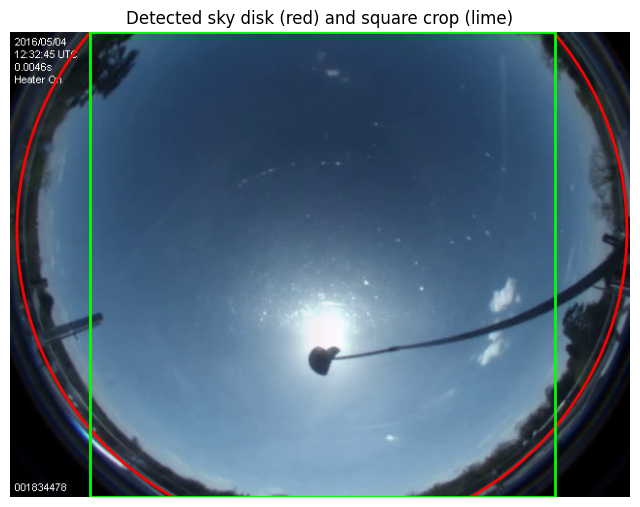

In [6]:
def detect_sky_circle(frame, thr=25):
    """Detect the circular sky disk. Returns (cx, cy, r) in pixels."""
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    mask = (gray > thr).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((15, 15), np.uint8))
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    biggest = max(cnts, key=cv2.contourArea)
    (cx, cy), r = cv2.minEnclosingCircle(biggest)
    return cx, cy, r


def square_crop_from_circle(cx, cy, r, w, h, margin=1.0):
    """Square crop box (x0, y0, x1, y1) around a circle, clamped to the frame.

    If the circle spills past the frame edges (e.g. the UOH imager, whose disk
    is clipped left/right), the square shrinks to fit the frame but stays
    centred on the circle instead of getting anchored to a corner.
    """
    side = min(int(round(2 * r * margin)), w, h)
    x0 = int(round(min(max(cx - side / 2, 0), w - side)))
    y0 = int(round(min(max(cy - side / 2, 0), h - side)))
    return x0, y0, x0 + side, y0 + side


def estimate_dataset_crop(paths, n_videos=8, thr=25):
    """Median square crop across midday frames from several videos."""
    rng = np.linspace(0, len(paths) - 1, num=min(n_videos, len(paths)), dtype=int)
    cs = []
    for i in rng:
        vr = VideoReader(str(paths[i]), ctx=cpu(0))
        fr = vr[len(vr) // 2].asnumpy()
        h, w = fr.shape[:2]
        cs.append(detect_sky_circle(fr, thr))
    cs = np.array(cs)
    cx, cy, r = np.median(cs, axis=0)
    return square_crop_from_circle(cx, cy, r, w, h), (cx, cy, r)


CROP, (cx, cy, r) = estimate_dataset_crop(video_paths, n_videos=8)
print(f"detected circle: center=({cx:.0f}, {cy:.0f}) r={r:.0f}")
print(f"CROP = {CROP}  -> {CROP[2] - CROP[0]}x{CROP[3] - CROP[1]}")

# Visualize the detected circle + square crop on a frame.
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(guide_frame)
ax.add_patch(plt.Circle((cx, cy), r, edgecolor="red", facecolor="none", linewidth=2))
ax.add_patch(plt.Rectangle((CROP[0], CROP[1]), CROP[2] - CROP[0], CROP[3] - CROP[1],
                           edgecolor="lime", facecolor="none", linewidth=2))
ax.set_title("Detected sky disk (red) and square crop (lime)")
ax.axis("off")
plt.show()

In [13]:
# CROP = (24, 0, 630, 480)
CROP = (88, 38, 1986, 1936)

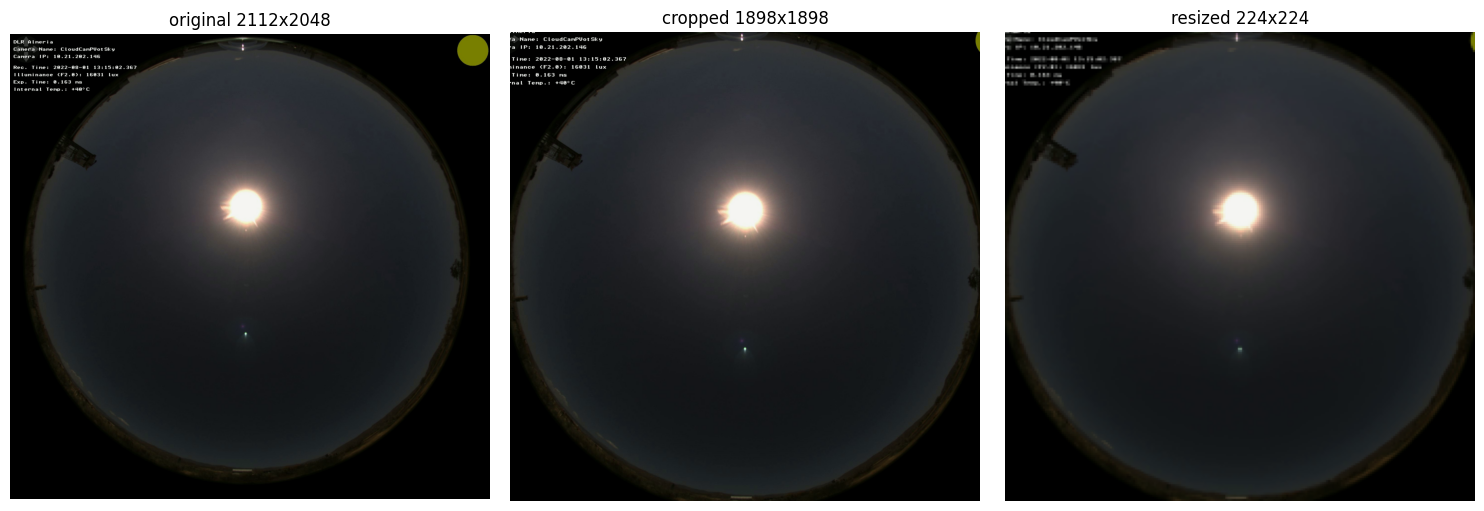

In [14]:
def preprocess_frame(frame, crop, size=224, interpolation=cv2.INTER_AREA):
    """Crop to the square ROI, then downscale to size x size (area-averaged)."""
    x0, y0, x1, y1 = crop
    cropped = frame[y0:y1, x0:x1]
    return cv2.resize(cropped, (size, size), interpolation=interpolation)

# Preview: original -> cropped -> 224x224
out = preprocess_frame(guide_frame, CROP, size=224)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(guide_frame);                       axes[0].set_title(f"original {guide_frame.shape[1]}x{guide_frame.shape[0]}")
axes[1].imshow(guide_frame[CROP[1]:CROP[3], CROP[0]:CROP[2]]); axes[1].set_title(f"cropped {CROP[2]-CROP[0]}x{CROP[3]-CROP[1]}")
axes[2].imshow(out);                               axes[2].set_title(f"resized {out.shape[1]}x{out.shape[0]}")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

(87, 33, 1985, 1931)


In [11]:
# Manual crop overrides, tuned by eye with the cells below. Datasets without
# an entry keep the auto-detected CROP from above.
MANUAL_CROPS = {
    "pangaea": (88, 38, 1986, 1936),
    "uoh": (20, 0, 590, 480)
}
CROP = MANUAL_CROPS.get(DATASET, CROP)
print(f"Using CROP = {CROP}  -> {CROP[2] - CROP[0]}x{CROP[3] - CROP[1]}")

Using CROP = (20, 0, 590, 480)  -> 570x480


## Export UOH LMDB

Pipeline for each frame:

1. Crop horizontally to `x ∈ [24, 630)`
2. Pad vertically with black until the frame is square
3. Downscale to 224×224 (`cv2.INTER_AREA`)
4. Encode and write into LMDB (one key per daily video)

Full-dataset build (long-running — prefer the script over this notebook cell):

```bash
# PNG is lossless but needs ~340 GB. With ~46 GB free, use JPEG q75 (~40 GB):
python build_uoh_lmdb.py --format jpg --jpeg-quality 75 --workers 16

# Lossless, if you have the disk:
# python build_uoh_lmdb.py --format png --workers 16
```

Output: `data/uoh_lmdb_224/frames.lmdb` plus `meta.json` / `videos.txt`.


In [ ]:
# UOH preprocess used by build_uoh_lmdb.py (horizontal crop + vertical pad + 224).
X1, X2, OUT_SIZE = 24, 630, 224

def preprocess_frame_uoh(frame, x1=X1, x2=X2, size=OUT_SIZE):
    """Crop x=[x1,x2), pad vertically to square, resize to size x size."""
    cropped = frame[:, x1:x2]
    h, w = cropped.shape[:2]
    side = max(h, w)
    pad_top = (side - h) // 2
    pad_bot = side - h - pad_top
    pad_left = (side - w) // 2
    pad_right = side - w - pad_left
    padded = cv2.copyMakeBorder(
        cropped, pad_top, pad_bot, pad_left, pad_right,
        cv2.BORDER_CONSTANT, value=(0, 0, 0),
    )
    return cv2.resize(padded, (size, size), interpolation=cv2.INTER_AREA)


# Preview on the guide frame (if available).
try:
    _prev = preprocess_frame_uoh(guide_frame)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(guide_frame); axes[0].set_title(f"original {guide_frame.shape[1]}x{guide_frame.shape[0]}")
    axes[0].axvline(X1, color="lime"); axes[0].axvline(X2, color="lime")
    axes[1].imshow(guide_frame[:, X1:X2]); axes[1].set_title(f"cropped {X2-X1}x{guide_frame.shape[0]}")
    axes[2].imshow(_prev); axes[2].set_title(f"pad+resize {_prev.shape[1]}x{_prev.shape[0]}")
    for a in axes: a.axis("off")
    plt.tight_layout(); plt.show()
except NameError:
    print("Run the earlier cells first to load guide_frame.")


## Export Pangaea LMDB

Pipeline for each frame (disk fully inside the frame — no pad needed):

1. Crop to `CROP = (88, 38, 1986, 1936)` → 1898×1898
2. Downscale to 224×224 (`cv2.INTER_AREA`)
3. Encode and write into LMDB (one key per daily video)

Full-dataset build (long-running — prefer the script over this notebook cell):

```bash
# ~47 GB free on this machine; JPG q75 is the safe default (~5–8 GB):
python build_pangaea_lmdb.py --format jpg --jpeg-quality 75 --workers 16

# Lossless, if you have the disk (~30–60 GB):
# python build_pangaea_lmdb.py --format png --workers 16

# Smoke test:
# python build_pangaea_lmdb.py --limit 3 --workers 4
```

Output: `data/pangaea_lmdb_224/frames.lmdb` plus `meta.json` / `videos.txt`.


In [ ]:
# Pangaea preprocess used by build_pangaea_lmdb.py (square crop + 224).
PANGAEA_CROP = (88, 38, 1986, 1936)
PANGAEA_OUT_SIZE = 224


def preprocess_frame_pangaea(frame, crop=PANGAEA_CROP, size=PANGAEA_OUT_SIZE):
    """Crop to the square sky disk, then resize to size x size."""
    x0, y0, x1, y1 = crop
    cropped = frame[y0:y1, x0:x1]
    return cv2.resize(cropped, (size, size), interpolation=cv2.INTER_AREA)


# Preview on the guide frame (if available).
try:
    x0, y0, x1, y1 = PANGAEA_CROP
    _prev = preprocess_frame_pangaea(guide_frame)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(guide_frame)
    axes[0].set_title(f"original {guide_frame.shape[1]}x{guide_frame.shape[0]}")
    axes[0].add_patch(plt.Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        edgecolor="lime", facecolor="none", linewidth=2))
    axes[1].imshow(guide_frame[y0:y1, x0:x1])
    axes[1].set_title(f"cropped {x1 - x0}x{y1 - y0}")
    axes[2].imshow(_prev)
    axes[2].set_title(f"resized {_prev.shape[1]}x{_prev.shape[0]}")
    for a in axes:
        a.axis("off")
    plt.tight_layout()
    plt.show()
except NameError:
    print("Run the earlier cells first to load guide_frame.")


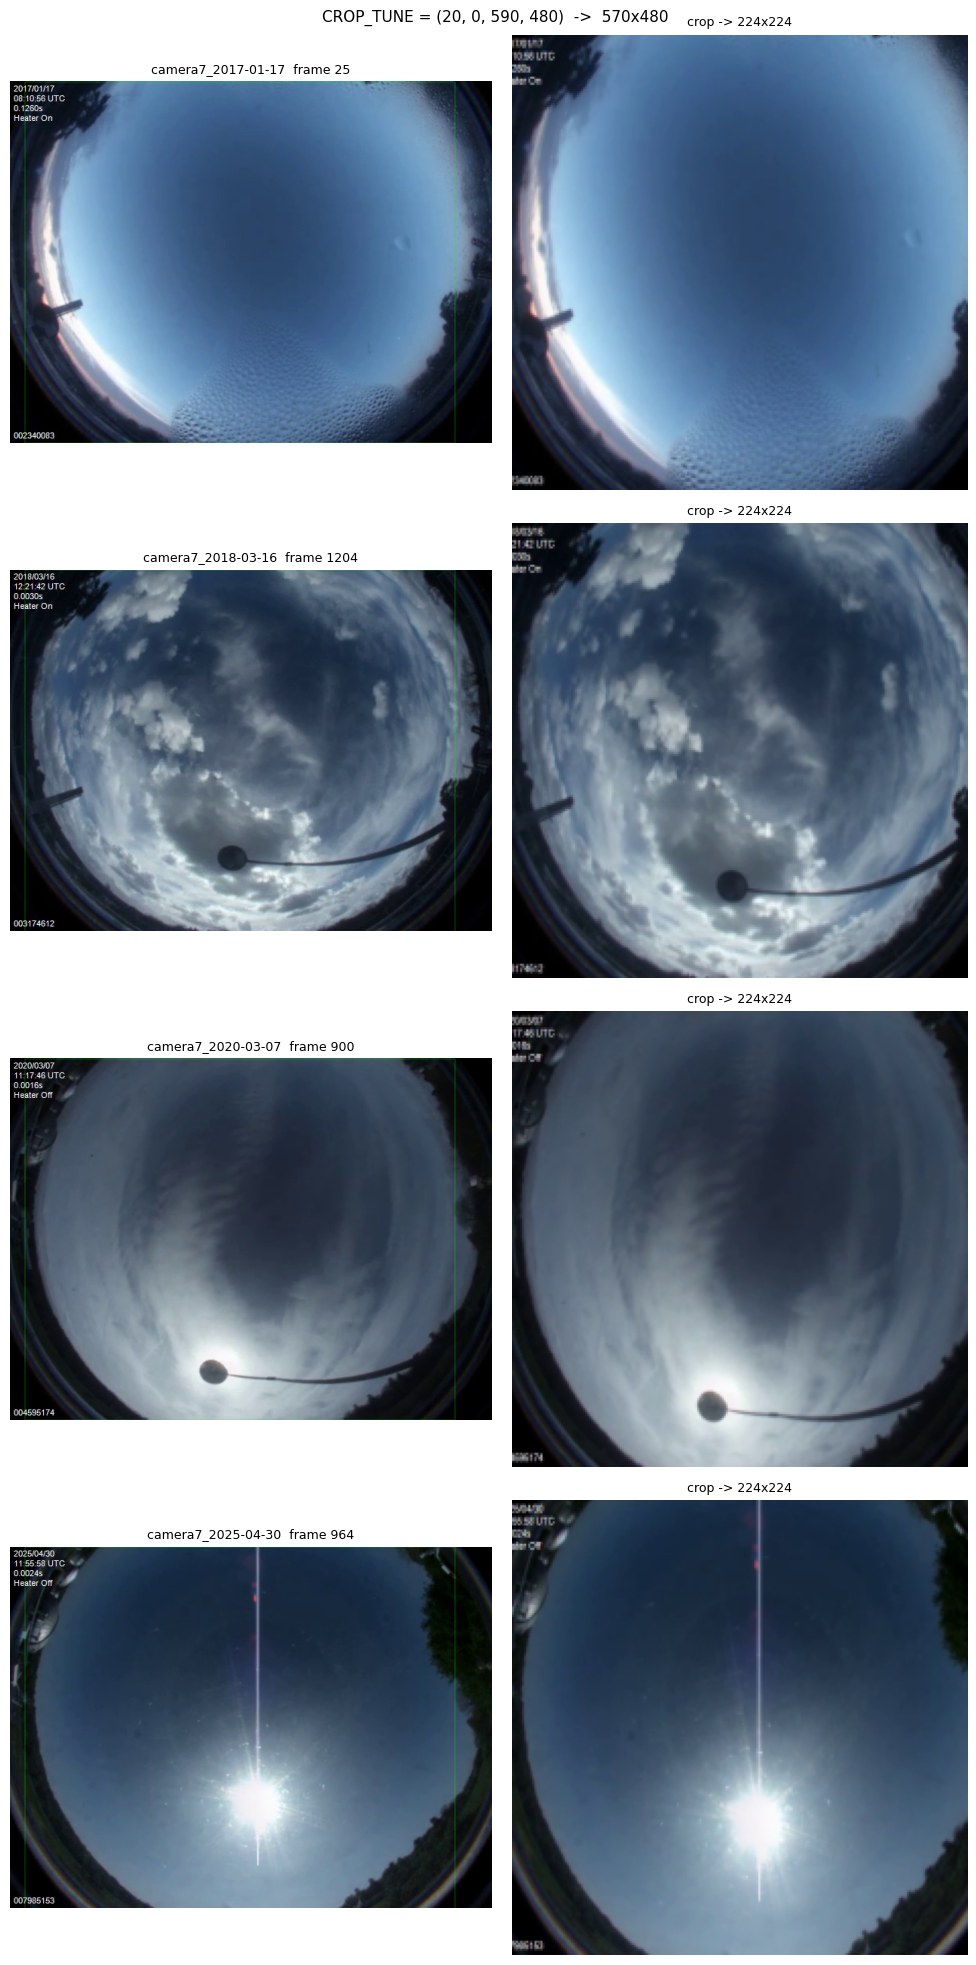

In [12]:
import random

# Tweak this and re-run until the lime box hugs the disk on every sample.
# Starts from the auto-detected CROP; edit the numbers to fine-tune.
CROP_TUNE = CROP            # (x0, y0, x1, y1)
N_SAMPLES = 4               # how many random frames to show each run

x0, y0, x1, y1 = CROP_TUNE
picks = random.sample(range(len(video_paths)), k=min(N_SAMPLES, len(video_paths)))

fig, axes = plt.subplots(len(picks), 2, figsize=(10, 5 * len(picks)))
axes = np.atleast_2d(axes)
for row, vi in enumerate(picks):
    vp = video_paths[vi]
    vr = VideoReader(str(vp), ctx=cpu(0))
    fi = random.randrange(len(vr))          # random frame within the day
    frame = vr[fi].asnumpy()

    # Left: full frame with the crop box.
    axes[row, 0].imshow(frame)
    axes[row, 0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                         edgecolor="lime", facecolor="none", linewidth=0.2))
    axes[row, 0].set_title(f"{vp.stem}  frame {fi}", fontsize=9)
    axes[row, 0].axis("off")

    # Right: resulting crop -> 224x224.
    axes[row, 1].imshow(preprocess_frame(frame, CROP_TUNE, size=224))
    axes[row, 1].set_title("crop -> 224x224", fontsize=9)
    axes[row, 1].axis("off")

fig.suptitle(f"CROP_TUNE = {CROP_TUNE}  ->  {x1 - x0}x{y1 - y0}", fontsize=11)
fig.tight_layout()
plt.show()